# 🧬 الگوریتم ژنتیک برای برازش منحنی پاسخ به دوز دارو

**هدف:** پیدا کردن ضرایب بهینه `a` و `b` در تابع سیگموید:

$$f(\text{dose}) = \frac{1}{1 + e^{-a(\text{dose} - b)}}$$

- **`a`** = شیب منحنی (چقدر تند تغییر می‌کند)
- **`b`** = نقطه میانی (EC50 — دوزی که پاسخ ۵۰٪ است)

---
**دو رویکرد:**
1. **دستی با NumPy** — گام‌به‌گام از صفر با گرادیان نزولی
2. **با PyGAD** — الگوریتم ژنتیک آماده

> نصب: `pip install pygad matplotlib numpy`

---
## ⚙️ ایمپورت کتابخانه‌ها

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import pygad

warnings.filterwarnings('ignore')
np.random.seed(42)

# تنظیمات نمودار
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FFFFFF',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

print('✅ کتابخانه‌ها با موفقیت بارگذاری شدند')
print(f'   NumPy  {np.__version__}   |   PyGAD  {pygad.__version__}')

✅ کتابخانه‌ها با موفقیت بارگذاری شدند
   NumPy  2.4.4   |   PyGAD  3.6.0


---
## 📊 مرحله ۱ — تولید داده مصنوعی (با نویز واقع‌گرایانه)

ضرایب واقعی را پنهان می‌کنیم؛ الگوریتم باید آن‌ها را پیدا کند.

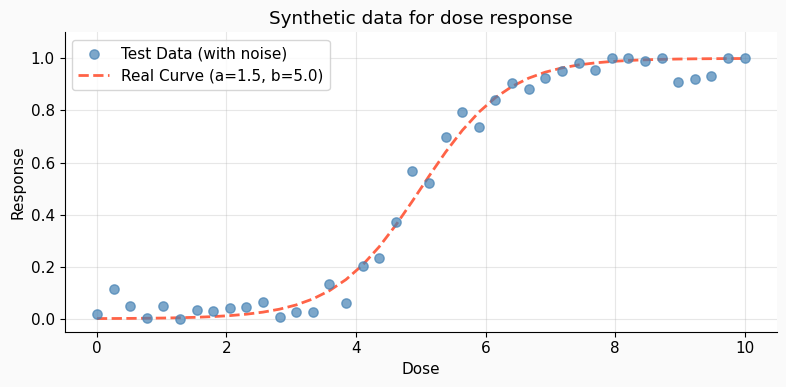

تعداد نقاط داده: 40
دامنه دوز: [0.0, 10.0]
ضرایب پنهان ← a = 1.5,  b = 5.0  (الگوریتم باید اینها را پیدا کند!)


In [16]:
# ─── ضرایب پنهان (پاسخ درست) ───────────────────────────
TRUE_A = 1.5   # شیب منحنی
TRUE_B = 5.0   # EC50 (نقطه ۵۰٪)

# ─── داده‌های اندازه‌گیری (با نویز آزمایشگاهی) ──────────
doses    = np.linspace(0, 10, 40)           # ۴۰ سطح دوز
true_resp = 1 / (1 + np.exp(-TRUE_A * (doses - TRUE_B)))
noise    = np.random.normal(0, 0.05, len(doses))  # نویز گاوسی
observed = np.clip(true_resp + noise, 0, 1)       # پاسخ مشاهده‌شده

# ─── نمایش داده‌ها ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(doses, observed, color='steelblue', s=45, alpha=0.7,
           label='Test Data (with noise)', zorder=3)
ax.plot(doses, true_resp, color='tomato', lw=2, ls='--',
        label=f'Real Curve (a={TRUE_A}, b={TRUE_B})')

ax.set(xlabel='Dose', ylabel='Response',
       title='Synthetic data for dose response')
ax.legend(loc='upper left')
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

print(f'تعداد نقاط داده: {len(doses)}')
print(f'دامنه دوز: [{doses.min():.1f}, {doses.max():.1f}]')
print(f'ضرایب پنهان ← a = {TRUE_A},  b = {TRUE_B}  (الگوریتم باید اینها را پیدا کند!)')

---
## 🔧 مرحله ۲ — تعریف توابع پایه

این توابع در هر دو روش (دستی و PyGAD) استفاده می‌شوند.

In [18]:
def sigmoid(dose, a, b):
    """
    تابع سیگموید — منحنی S شکل پاسخ به دوز
    a: شیب (steepness)
    b: EC50 — دوزی که پاسخ = ۰.۵
    """
    return 1 / (1 + np.exp(-a * (dose - b)))


def mse_loss(a, b, doses=doses, observed=observed):
    """میانگین مجذور خطا — هر چه کمتر، برازش بهتر"""
    predicted = sigmoid(doses, a, b)
    return np.mean((predicted - observed) ** 2)


def plot_fit(a, b, title, color='darkorange', history=None, ax_hist=None):
    """نمایش برازش منحنی روی داده‌ها"""
    dose_fine = np.linspace(0, 10, 300)
    
    ncols = 2 if history is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7*ncols, 4))
    if ncols == 1:
        axes = [axes]
    
    # نمودار برازش
    ax = axes[0]
    ax.scatter(doses, observed, color='steelblue', s=40, alpha=0.6,
               label='Observed Data', zorder=3)
    ax.plot(dose_fine, sigmoid(dose_fine, TRUE_A, TRUE_B),
            'r--', lw=1.5, alpha=0.5, label='Real Curve')
    ax.plot(dose_fine, sigmoid(dose_fine, a, b),
            color=color, lw=2.5, label=f'Fitting: a={a:.3f}, b={b:.3f}')
    ax.axvline(b, color=color, ls=':', alpha=0.5)
    ax.set(xlabel='Dose', ylabel='Response',
           title=f'{title}\nMSE = {mse_loss(a,b):.5f}')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.1)
    
    # نمودار تاریخچه خطا
    if history is not None:
        ax2 = axes[1]
        ax2.plot(history, color=color, lw=2)
        ax2.set(xlabel='iteration / generation', ylabel='Loss (MSE)',
                title='Loss during generations')
        ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()


# ─── تست سریع ───────────────────────────────────────────
print('توابع تعریف شدند.')
print(f'MSE با ضرایب درست  (a={TRUE_A}, b={TRUE_B}): {mse_loss(TRUE_A, TRUE_B):.4f}')

توابع تعریف شدند.
MSE با ضرایب درست  (a=1.5, b=5.0): 0.0021


---
## 🗺️ مرحله ۳ — نقشه سطح خطا (Loss Landscape)

قبل از بهینه‌سازی ببینیم فضای جستجو چگونه است.

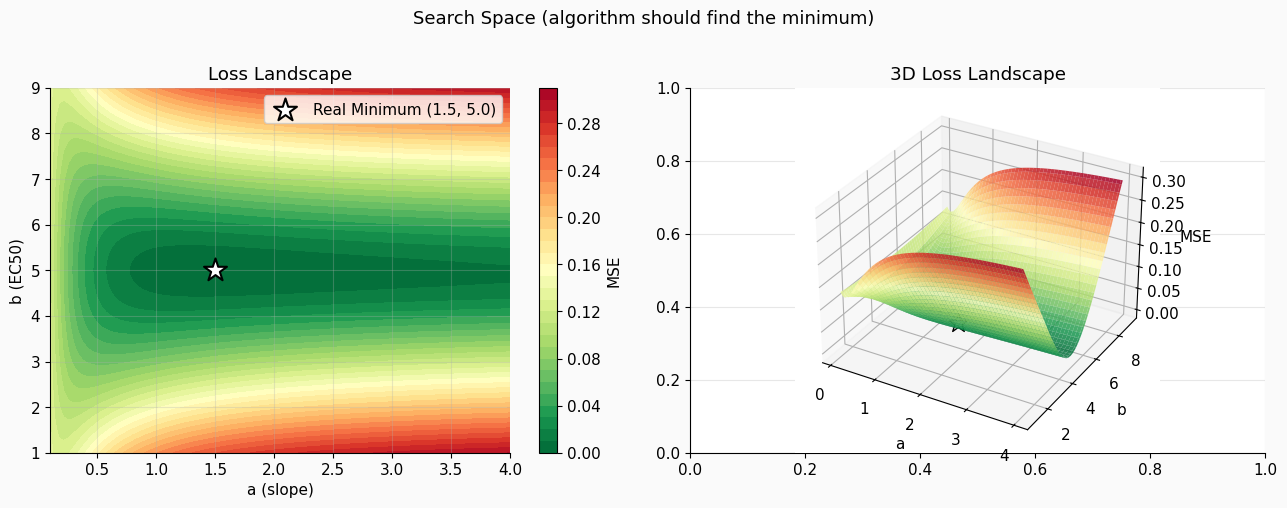

⭐ ستاره سفید = جواب بهینه واقعی
🟢 سبز = خطای کم (جواب خوب) | 🔴 قرمز = خطای زیاد (جواب بد)


In [20]:
a_range = np.linspace(0.1, 4.0, 100)
b_range = np.linspace(1.0, 9.0, 100)
A_grid, B_grid = np.meshgrid(a_range, b_range)

# محاسبه MSE برای هر ترکیب (a, b)
Z = np.array([
    [mse_loss(a, b) for a in a_range]
    for b in b_range
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# نمودار Contour
ax = axes[0]
cp = ax.contourf(A_grid, B_grid, Z, levels=30, cmap='RdYlGn_r')
fig.colorbar(cp, ax=ax, label='MSE')
ax.scatter(TRUE_A, TRUE_B, marker='*', s=300, color='white',
           edgecolors='black', lw=1.5, label=f'Real Minimum ({TRUE_A}, {TRUE_B})', zorder=5)
ax.set(xlabel='a (slope)', ylabel='b (EC50)',
       title='Loss Landscape')
ax.legend()

# نمودار 3D
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.plot_surface(A_grid, B_grid, Z, cmap='RdYlGn_r', alpha=0.85, linewidth=0)
ax3d.scatter(TRUE_A, TRUE_B, mse_loss(TRUE_A, TRUE_B),
             marker='*', s=200, color='white', edgecolors='black')
ax3d.set(xlabel='a', ylabel='b', zlabel='MSE',
         title='3D Loss Landscape')

plt.suptitle('Search Space (algorithm should find the minimum)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('⭐ ستاره سفید = جواب بهینه واقعی')
print('🟢 سبز = خطای کم (جواب خوب) | 🔴 قرمز = خطای زیاد (جواب بد)')

---
# روش اول: بهینه‌سازی دستی با NumPy
## 🔢 مرحله ۴ — الگوریتم ژنتیک از صفر

همان منطق آموزشی قبل، این بار برای یافتن `a` و `b`.

In [21]:
# ════════════════════════════════════════════════
#   تنظیمات الگوریتم ژنتیک دستی
# ════════════════════════════════════════════════
POP_SIZE      = 30       # تعداد افراد
N_GENERATIONS = 200      # تعداد نسل‌ها
MUTATION_STD  = 0.15     # شدت جهش (انحراف گاوسی)
ELITISM_K     = 4        # تعداد نخبگانی که مستقیم منتقل می‌شوند

# محدوده جستجو
A_MIN, A_MAX = 0.1, 5.0
B_MIN, B_MAX = 1.0, 9.0


# ─── ۱. جمعیت اولیه تصادفی ──────────────────────────────
def init_population(n):
    """n فرد تصادفی در فضای جستجو"""
    a_vals = np.random.uniform(A_MIN, A_MAX, n)
    b_vals = np.random.uniform(B_MIN, B_MAX, n)
    return np.column_stack([a_vals, b_vals])  # شکل: (n, 2)


# ─── ۲. تابع شایستگی ────────────────────────────────────
def fitness_population(pop):
    """
    شایستگی = -MSE  (بزرگتر = بهتر)
    منفی می‌کنیم چون می‌خواهیم بیشینه کنیم
    """
    return np.array([-mse_loss(ind[0], ind[1]) for ind in pop])


# ─── ۳. انتخاب با چرخ رولت ──────────────────────────────
def roulette_select(pop, fitnesses, n_select):
    """احتمال انتخاب متناسب با شایستگی"""
    shifted = fitnesses - fitnesses.min() + 1e-9  # اطمینان از مثبت بودن
    probs = shifted / shifted.sum()
    indices = np.random.choice(len(pop), size=n_select, p=probs)
    return pop[indices]


# ─── ۴. تقاطع (Arithmetic Crossover) ────────────────────
def crossover(parent1, parent2):
    """
    تقاطع حسابی: ترکیب وزن‌دار دو والد
    α تصادفی بین ۰ تا ۱
    """
    alpha = np.random.rand()
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = (1 - alpha) * parent1 + alpha * parent2
    return child1, child2


# ─── ۵. جهش گاوسی ───────────────────────────────────────
def mutate(individual, std=MUTATION_STD):
    """
    اضافه کردن نویز گاوسی به هر ژن
    سپس کلیپ کردن در محدوده مجاز
    """
    mutated = individual + np.random.normal(0, std, size=2)
    mutated[0] = np.clip(mutated[0], A_MIN, A_MAX)
    mutated[1] = np.clip(mutated[1], B_MIN, B_MAX)
    return mutated


print('✅ توابع الگوریتم ژنتیک دستی آماده شدند')
# تست سریع
pop_test = init_population(5)
fit_test = fitness_population(pop_test)
print(f'نمونه جمعیت اولیه (۵ فرد):')
for i, (ind, f) in enumerate(zip(pop_test, fit_test)):
    print(f'  فرد {i+1}: a={ind[0]:.3f}, b={ind[1]:.3f}  →  MSE={-f:.4f}')

✅ توابع الگوریتم ژنتیک دستی آماده شدند
نمونه جمعیت اولیه (۵ فرد):
  فرد 1: a=1.026, b=1.912  →  MSE=0.1561
  فرد 2: a=1.909, b=3.798  →  MSE=0.0395
  فرد 3: a=4.102, b=3.242  →  MSE=0.0978
  فرد 4: a=0.336, b=7.632  →  MSE=0.0914
  فرد 5: a=2.968, b=8.744  →  MSE=0.2671


## ▶️ مرحله ۵ — اجرای الگوریتم ژنتیک دستی

In [22]:
np.random.seed(42)

# ─── مقداردهی اولیه ─────────────────────────────────────
population  = init_population(POP_SIZE)
history_mse = []          # تاریخچه بهترین MSE هر نسل
history_pop = []          # ذخیره جمعیت برای انیمیشن
best_ever   = None
best_fit    = -np.inf

# ─── حلقه اصلی ──────────────────────────────────────────
for gen in range(N_GENERATIONS):
    fitnesses = fitness_population(population)
    
    # ثبت بهترین این نسل
    best_idx = np.argmax(fitnesses)
    if fitnesses[best_idx] > best_fit:
        best_fit  = fitnesses[best_idx]
        best_ever = population[best_idx].copy()
    history_mse.append(-best_fit)
    
    # ذخیره جمعیت هر ۵۰ نسل برای نمایش
    if gen % 50 == 0 or gen == N_GENERATIONS - 1:
        history_pop.append((gen, population.copy(), fitnesses.copy()))
    
    # ─── نخبه‌گرایی ───────────────────────────────────────
    elite_idx  = np.argsort(fitnesses)[-ELITISM_K:]
    elites     = population[elite_idx]
    
    # ─── ساخت نسل جدید ────────────────────────────────────
    new_pop = list(elites)
    parents = roulette_select(population, fitnesses, POP_SIZE)
    
    i = 0
    while len(new_pop) < POP_SIZE:
        p1 = parents[i % len(parents)]
        p2 = parents[(i + 1) % len(parents)]
        c1, c2 = crossover(p1, p2)
        new_pop.append(mutate(c1))
        if len(new_pop) < POP_SIZE:
            new_pop.append(mutate(c2))
        i += 2
    
    population = np.array(new_pop[:POP_SIZE])

a_found, b_found = best_ever
print('=' * 55)
print('📌 نتیجه الگوریتم ژنتیک دستی:')
print(f'   a پیدا شده : {a_found:.4f}   |   a واقعی : {TRUE_A}')
print(f'   b پیدا شده : {b_found:.4f}   |   b واقعی : {TRUE_B}')
print(f'   MSE نهایی  : {mse_loss(a_found, b_found):.6f}')
print('=' * 55)

📌 نتیجه الگوریتم ژنتیک دستی:
   a پیدا شده : 1.5618   |   a واقعی : 1.5
   b پیدا شده : 4.9752   |   b واقعی : 5.0
   MSE نهایی  : 0.002070


## 📈 مرحله ۶ — نمایش نتایج دستی

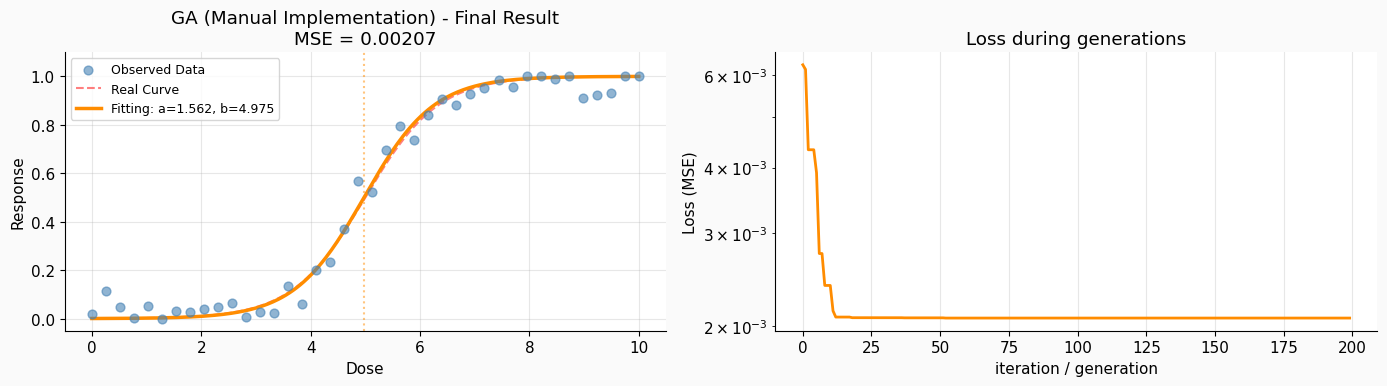

In [23]:
# ─── نمودار ۱: برازش نهایی + روند خطا ──────────────────
plot_fit(a_found, b_found,
         title='GA (Manual Implementation) - Final Result',
         color='darkorange',
         history=history_mse)

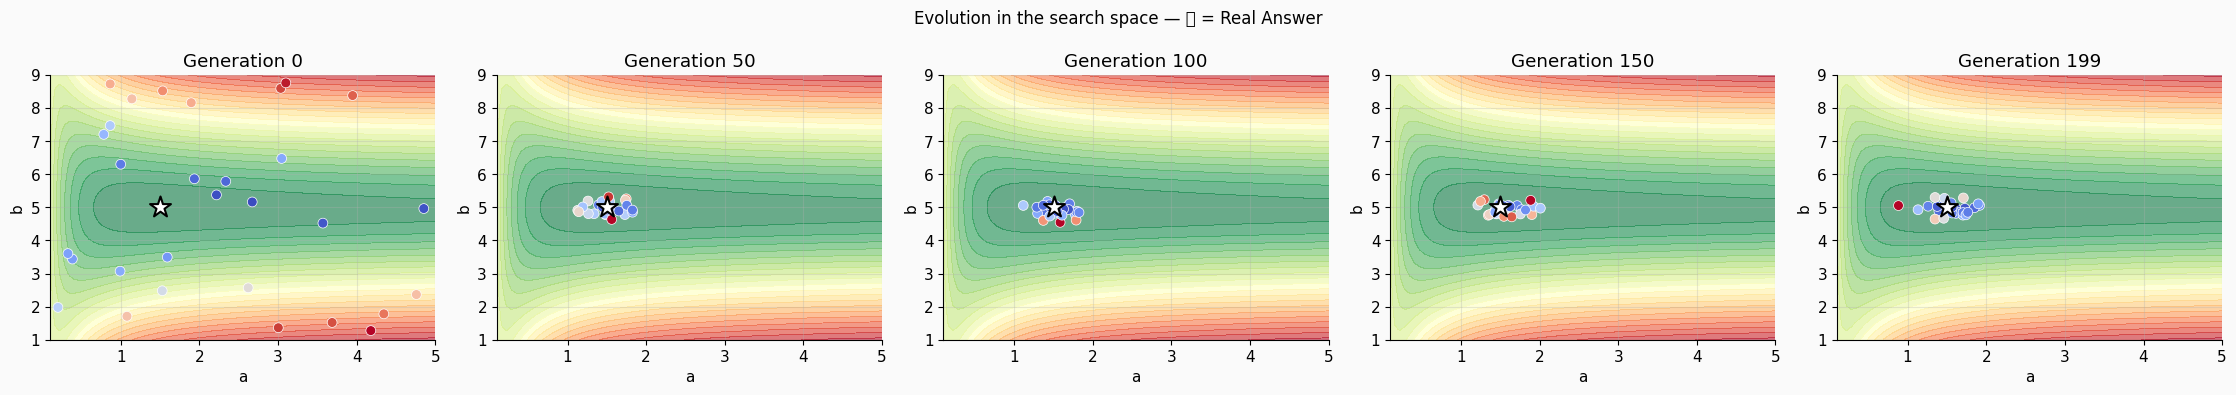

نکته: جمعیت از پراکندگی تصادفی به تمرکز حول جواب بهینه می‌رسد.


In [24]:
# ─── نمودار ۲: تکامل جمعیت در فضای (a, b) ──────────────
fig, axes = plt.subplots(1, len(history_pop), figsize=(4.5*len(history_pop), 4))
if len(history_pop) == 1:
    axes = [axes]

# نقشه پس‌زمینه
a_g = np.linspace(A_MIN, A_MAX, 80)
b_g = np.linspace(B_MIN, B_MAX, 80)
Ag, Bg = np.meshgrid(a_g, b_g)
Zg = np.array([[mse_loss(a, b) for a in a_g] for b in b_g])

for ax, (gen, pop, fits) in zip(axes, history_pop):
    ax.contourf(Ag, Bg, Zg, levels=20, cmap='RdYlGn_r', alpha=0.6)
    sc = ax.scatter(pop[:, 0], pop[:, 1],
                    c=-fits, cmap='coolwarm', s=50,
                    edgecolors='white', lw=0.5, zorder=4)
    ax.scatter(TRUE_A, TRUE_B, marker='*', s=250,
               color='white', edgecolors='black', lw=1.5, zorder=5)
    ax.set(xlabel='a', ylabel='b',
           title=f'Generation {gen}',
           xlim=(A_MIN, A_MAX), ylim=(B_MIN, B_MAX))

plt.suptitle('Evolution in the search space — ⭐ = Real Answer', fontsize=12)
plt.tight_layout()
plt.show()

print('نکته: جمعیت از پراکندگی تصادفی به تمرکز حول جواب بهینه می‌رسد.')

---
# روش دوم: با کتابخانه PyGAD
## 🤖 مرحله ۷ — راه‌اندازی PyGAD

PyGAD همه مراحل را خودکار می‌کند — فقط تابع fitness و تنظیمات لازم است.

In [25]:
# ─── تابع شایستگی برای PyGAD ────────────────────────────
# PyGAD انتظار دارد: fitness_func(ga_instance, solution, solution_idx)
def pygad_fitness(ga_instance, solution, solution_idx):
    """
    solution[0] = a
    solution[1] = b
    برمی‌گرداند: -MSE (PyGAD بیشینه می‌کند)
    """
    a, b = solution[0], solution[1]
    return -mse_loss(a, b)


# ─── ذخیره تاریخچه هر نسل ───────────────────────────────
pygad_history = []

def on_generation(ga_instance):
    """هر نسل صدا زده می‌شود — تاریخچه را ذخیره می‌کند"""
    sol, fit, _ = ga_instance.best_solution()
    pygad_history.append(-fit)  # MSE
    if ga_instance.generations_completed % 50 == 0:
        gen = ga_instance.generations_completed
        print(f'  نسل {gen:>3}: a={sol[0]:.3f}  b={sol[1]:.3f}  MSE={-fit:.5f}')


# ─── ساخت نمونه PyGAD ────────────────────────────────────
ga_instance = pygad.GA(
    # ────── پارامترهای اصلی ──────
    num_generations      = 300,        # تعداد نسل‌ها
    sol_per_pop          = 40,         # اندازه جمعیت
    num_genes            = 2,          # تعداد پارامترها (a و b)
    
    # ────── محدوده ژن‌ها ──────────
    gene_space           = [
        {'low': A_MIN, 'high': A_MAX},  # محدوده a
        {'low': B_MIN, 'high': B_MAX},  # محدوده b
    ],
    
    # ────── شایستگی و انتخاب ──────
    fitness_func         = pygad_fitness,
    num_parents_mating   = 10,
    parent_selection_type= 'rws',      # rws = چرخ رولت
    
    # ────── تقاطع ─────────────────
    crossover_type       = 'two_points', # تقاطع حسابی
    crossover_probability= 0.85,
    
    # ────── جهش ───────────────────
    mutation_type        = 'random',
    mutation_percent_genes= 30,        # ۳۰٪ ژن‌ها جهش می‌کنند
    
    # ────── نخبه‌گرایی ────────────
    keep_elitism         = 3,          # ۳ بهترین مستقیم منتقل می‌شوند
    
    # ────── کال‌بک و تنظیمات ──────
    on_generation        = on_generation,
    random_seed          = 42,
    suppress_warnings    = True,
)

print('✅ PyGAD آماده اجرا')
print(f'   جمعیت: {ga_instance.sol_per_pop} | نسل‌ها: {ga_instance.num_generations}')
print(f'   تقاطع: arithmetic | انتخاب: roulette wheel | جهش: random')

✅ PyGAD آماده اجرا
   جمعیت: 40 | نسل‌ها: 300
   تقاطع: arithmetic | انتخاب: roulette wheel | جهش: random


## ▶️ مرحله ۸ — اجرای PyGAD

In [26]:
print('🚀 شروع اجرای PyGAD...')
print('─' * 45)

ga_instance.run()

# ─── استخراج بهترین جواب ────────────────────────────────
solution, solution_fitness, _ = ga_instance.best_solution()
a_pygad, b_pygad = solution

print('─' * 45)
print('\n📌 نتیجه PyGAD:')
print(f'   a پیدا شده : {a_pygad:.4f}   |   a واقعی : {TRUE_A}')
print(f'   b پیدا شده : {b_pygad:.4f}   |   b واقعی : {TRUE_B}')
print(f'   MSE نهایی  : {mse_loss(a_pygad, b_pygad):.6f}')

🚀 شروع اجرای PyGAD...
─────────────────────────────────────────────
  نسل  50: a=1.348  b=5.034  MSE=0.00240
  نسل 100: a=1.348  b=5.034  MSE=0.00240
  نسل 150: a=1.550  b=4.896  MSE=0.00223
  نسل 200: a=1.529  b=4.994  MSE=0.00208
  نسل 250: a=1.529  b=4.994  MSE=0.00208
  نسل 300: a=1.529  b=4.994  MSE=0.00208
─────────────────────────────────────────────

📌 نتیجه PyGAD:
   a پیدا شده : 1.5287   |   a واقعی : 1.5
   b پیدا شده : 4.9942   |   b واقعی : 5.0
   MSE نهایی  : 0.002082


## 📈 مرحله ۹ — نمایش نتایج PyGAD

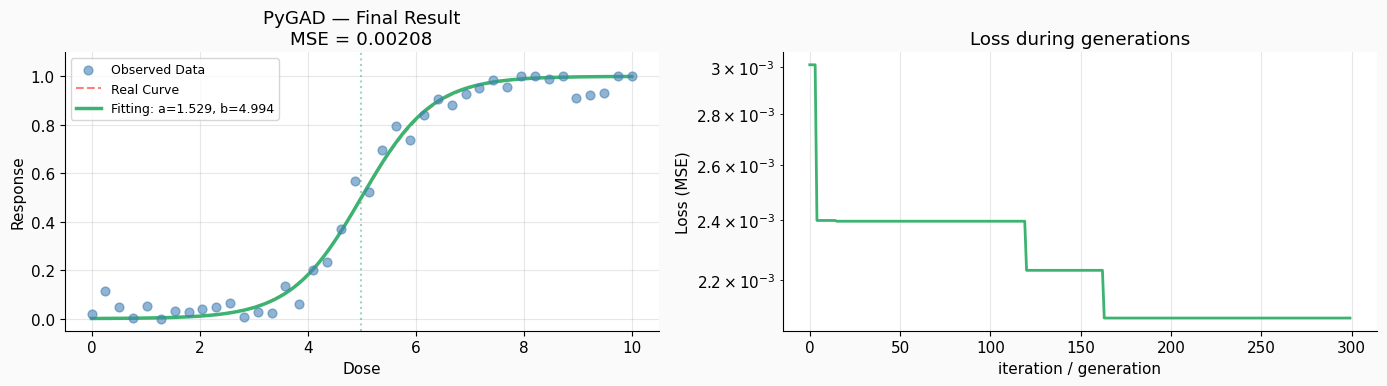

In [27]:
# برازش نهایی + تاریخچه خطا
plot_fit(a_pygad, b_pygad,
         title='PyGAD — Final Result',
         color='mediumseagreen',
         history=pygad_history)

---
## 🏆 مرحله ۱۰ — مقایسه نهایی دو روش

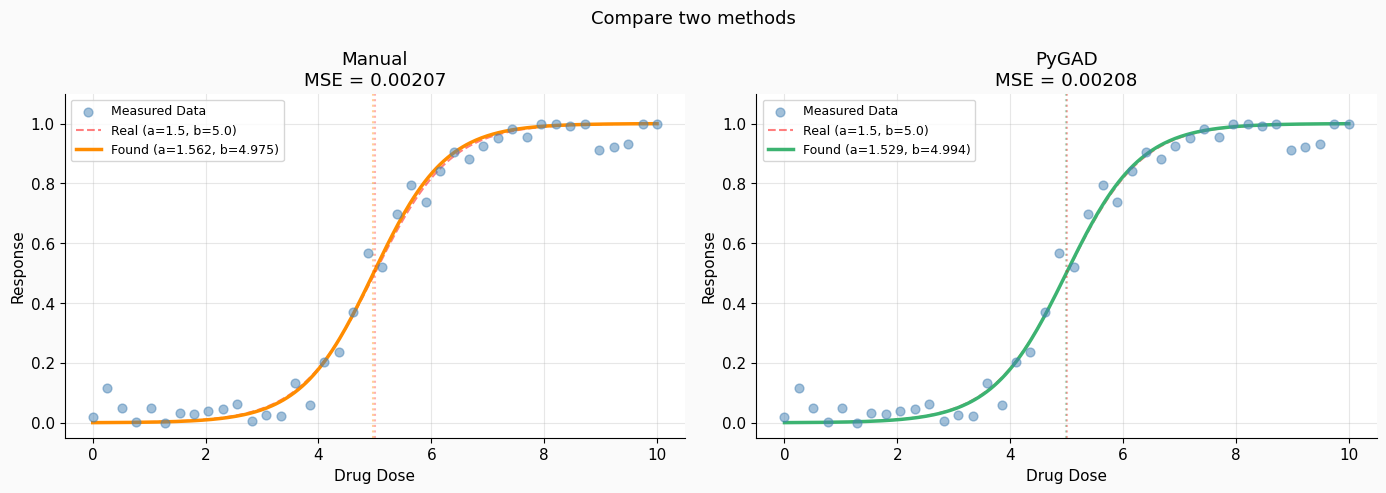


════════════════════════════════════════════════════════════
پارامتر                   واقعی      GA دستی        PyGAD
────────────────────────────────────────────────────────────
a (شیب)                  1.5000       1.5618       1.5287
b (EC50)                 5.0000       4.9752       4.9942
MSE                         0.0     0.002070     0.002082
════════════════════════════════════════════════════════════

🏅 برنده این دور: PyGAD


In [29]:
# ─── نمودار مقایسه برازش ────────────────────────────────
dose_fine = np.linspace(0, 10, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_and_params = [
    ('Manual', a_found,  b_found,  'darkorange',     axes[0]),
    ('PyGAD',                         a_pygad,  b_pygad,  'mediumseagreen', axes[1]),
]

for title_str, a, b, color, ax in labels_and_params:
    ax.scatter(doses, observed, color='steelblue', s=40, alpha=0.5,
               label='Measured Data', zorder=3)
    ax.plot(dose_fine, sigmoid(dose_fine, TRUE_A, TRUE_B),
            'r--', lw=1.5, alpha=0.5, label=f'Real (a={TRUE_A}, b={TRUE_B})')
    ax.plot(dose_fine, sigmoid(dose_fine, a, b),
            color=color, lw=2.5,
            label=f'Found (a={a:.3f}, b={b:.3f})')
    ax.axvline(b, color=color, ls=':', alpha=0.4)
    ax.axvline(TRUE_B, color='red', ls=':', alpha=0.3)
    ax.set(xlabel='Drug Dose', ylabel='Response',
           title=f'{title_str}\nMSE = {mse_loss(a,b):.5f}')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.1)

plt.suptitle('Compare two methods', fontsize=13)
plt.tight_layout()
plt.show()


# ─── جدول مقایسه ───────────────────────────────────────
print('\n' + '═'*60)
print(f'{"پارامتر":<20} {"واقعی":>10} {"GA دستی":>12} {"PyGAD":>12}')
print('─'*60)
print(f'{"a (شیب)":<20} {TRUE_A:>10.4f} {a_found:>12.4f} {a_pygad:>12.4f}')
print(f'{"b (EC50)":<20} {TRUE_B:>10.4f} {b_found:>12.4f} {b_pygad:>12.4f}')
print(f'{"MSE":<20} {0.0:>10} {mse_loss(a_found, b_found):>12.6f} {mse_loss(a_pygad, b_pygad):>12.6f}')
print('═'*60)

err_manual = abs(a_found - TRUE_A) + abs(b_found - TRUE_B)
err_pygad  = abs(a_pygad  - TRUE_A) + abs(b_pygad  - TRUE_B)
winner = 'GA دستی' if err_manual < err_pygad else 'PyGAD'
print(f'\n🏅 برنده این دور: {winner}')

---
## 🧪 آزمایش جدید با ضرایب دلخواه

مقادیر `MY_A` و `MY_B` را تغییر دهید و نتایج را مشاهده کنید!

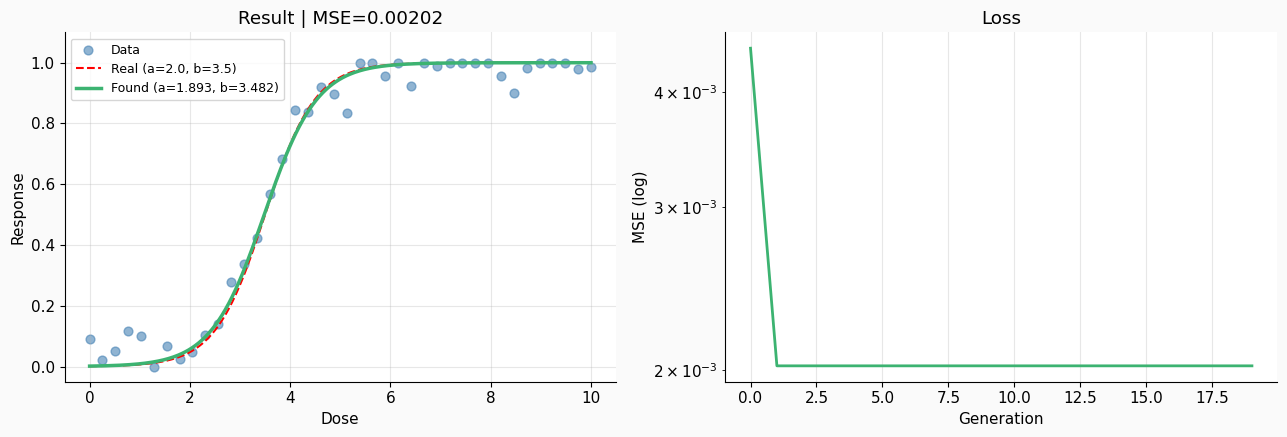

a پیدا شده: 1.8929  |  a واقعی: 2.0
b پیدا شده: 3.4822  |  b واقعی: 3.5


In [40]:
# ──── اینجا تغییر بدهید ────
MY_A = 2.0   # شیب منحنی
MY_B = 3.5   # EC50
# ───────────────────────────

np.random.seed(0)
new_response = sigmoid(doses, MY_A, MY_B) + np.random.normal(0, 0.05, len(doses))
new_response = np.clip(new_response, 0, 1)

def mse_new(a, b):
    return np.mean((sigmoid(doses, a, b) - new_response)**2)

# اجرای سریع PyGAD
hist_new = []
ga_new = pygad.GA(
    num_generations=20, sol_per_pop=30, num_genes=2,
    gene_space=[{'low':0.1,'high':5.0},{'low':0.5,'high':9.5}],
    fitness_func=lambda ga,sol,_: -mse_new(sol[0], sol[1]),
    num_parents_mating=8, parent_selection_type='rws',
    crossover_type='two_points', mutation_percent_genes=25,
    keep_elitism=2, random_seed=7, suppress_warnings=True,
    on_generation=lambda ga: hist_new.append(-ga.best_solution()[1])
)
ga_new.run()
sol_new, fit_new, _ = ga_new.best_solution()

# نمایش
dose_fine = np.linspace(0, 10, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(doses, new_response, color='steelblue', s=40, alpha=0.6, label='Data')
axes[0].plot(dose_fine, sigmoid(dose_fine, MY_A, MY_B), 'r--', lw=1.5, label=f'Real (a={MY_A}, b={MY_B})')
axes[0].plot(dose_fine, sigmoid(dose_fine, sol_new[0], sol_new[1]), 'mediumseagreen', lw=2.5,
             label=f'Found (a={sol_new[0]:.3f}, b={sol_new[1]:.3f})')
axes[0].set(xlabel='Dose', ylabel='Response', title=f'Result | MSE={mse_new(*sol_new):.5f}')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.1)

axes[1].plot(hist_new, color='mediumseagreen', lw=2)
axes[1].set(xlabel='Generation', ylabel='MSE (log)', title='Loss', yscale='log')

plt.tight_layout()
plt.show()

print(f'a پیدا شده: {sol_new[0]:.4f}  |  a واقعی: {MY_A}')
print(f'b پیدا شده: {sol_new[1]:.4f}  |  b واقعی: {MY_B}')

---
## 📚 خلاصه مفاهیم کلیدی

| مرحله | GA دستی | PyGAD |
|-------|---------|-------|
| کروموزوم | `np.array([a, b])` | `solution` |
| شایستگی | `−MSE` | `fitness_func` |
| انتخاب | چرخ رولت | `parent_selection_type='rws'` |
| تقاطع | حسابی (α·p1 + (1−α)·p2) | `crossover_type='arithmetic'` |
| جهش | نویز گاوسی | `mutation_type='random'` |
| نخبه‌گرایی | `k` بهترین مستقیم | `keep_elitism=k` |

**نکات مهم:**
- **جهش گاوسی** برای پارامترهای پیوسته بهتر از جهش باینری عمل می‌کند
- **تقاطع حسابی** برای اعداد اعشاری طبیعی‌تر از تقاطع نقطه‌ای است
- **نخبه‌گرایی** از فراموش شدن بهترین جواب‌های قبلی جلوگیری می‌کند
- **نرخ جهش بالا** تنوع را حفظ می‌کند اما همگرایی را کند می‌کند